# NB1: 数据获取与清洗

## 研究假设
> 高质量、结构化的历史K线数据是策略回测可靠性的基础。本Notebook的目标是构建一个**可复用、可扩展**的数据管道，为后续所有策略Notebook提供统一的数据接口。

## 决策日志
| 决策 | 选择 | 为什么 |
|------|------|--------|
| 交易所 | Binance | 全球交易量最大，API稳定，ccxt支持完善 |
| 交易对 | BTC/USDT | 流动性最佳，滑点影响最小，研究文献最多 |
| 时间粒度 | 1h K线 | 平衡信号频率与噪声，日线太慢、分钟线噪声过大 |
| 回测周期 | 2021-01 至 2024-12 | 覆盖牛市(2021)、熊市(2022)、震荡复苏(2023-2024) |
| 数据格式 | Parquet | 列式存储，读取速度远快于CSV，支持类型保留 |

---
## 1. 环境准备

In [1]:
!pip install ccxt pandas pyarrow matplotlib seaborn tqdm scipy

   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/27.5 MB ? eta -:--:--
    --------------------------------------- 0.5/27.5 MB 1.6 MB/s eta 0:00:18
    --------------------------------------- 0.5/27.5 MB 1.6 MB/s eta 0:00:18
   - -------------------------------------- 0.8/27.5 MB 1.2 MB/s eta 0:00:23
   - -------------------------------------- 1.3/27.5 MB 1.3 MB/s eta 0:00:21
   -- ------------------------------------- 1.6/27.5 MB 1.4 MB/s eta 0:00:19
   -- ------------------------------------- 1.8/27.5 MB 1.5 MB/s eta 0:00:18
   --- ------------------------------------ 2.1/27.5 MB 1.3 MB/s eta 0:00:20
   --- ------------------------------------ 2.1/27.5 MB 1.3 MB/s eta 0:00:20
   --- ---------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm.notebook import tqdm
import time
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print(f"ccxt版本: {ccxt.__version__}")
print(f"pandas版本: {pd.__version__}")

ccxt版本: 4.5.45
pandas版本: 2.3.3


---
## 2. 配置参数

将所有可调参数集中管理，方便后续扩展到其他交易对或时间范围。

In [3]:
CONFIG = {
    'exchange': 'binance',
    'symbol': 'BTC/USDT',
    'timeframe': '1h',
    'start_date': '2021-01-01',
    'end_date': '2024-12-31',
    'rate_limit_ms': 100,
    'batch_size': 1000,
    'data_dir': '../data',
}

os.makedirs(CONFIG['data_dir'], exist_ok=True)
print(f"目标: {CONFIG['symbol']} {CONFIG['timeframe']} K线")
print(f"周期: {CONFIG['start_date']} → {CONFIG['end_date']}")

目标: BTC/USDT 1h K线
周期: 2021-01-01 → 2024-12-31


---
## 3. 数据获取

Binance API单次最多返回1000条K线，所以需要**分页拉取**：从起始日期开始，每次拉1000条，用最后一条的时间戳作为下次请求的起点，循环直到结束日期。

In [13]:
exchange = ccxt.binance({
    'enableRateLimit': True,
    'proxies': {
        'http': 'http://127.0.0.1:7897',
        'https': 'http://127.0.0.1:7897',
    },
})
try:
    ticker = exchange.fetch_ticker('BTC/USDT')
    print(f"连接成功，BTC当前价格: {ticker['last']}")
except Exception as e:
    print(f"连接失败: {e}")

连接成功，BTC当前价格: 66846.2


In [14]:
def fetch_ohlcv(config):
    """分页获取历史K线数据"""
    exchange = getattr(ccxt, config['exchange'])({
        'enableRateLimit': True,
        'rateLimit': config['rate_limit_ms'],
        'proxies': {
            'http': 'http://127.0.0.1:7897',
            'https': 'http://127.0.0.1:7897',
        },
    })
    
    since = int(pd.Timestamp(config['start_date']).timestamp() * 1000)
    end_ts = int(pd.Timestamp(config['end_date']).timestamp() * 1000)
    
    all_candles = []
    
    with tqdm(desc='拉取K线数据', unit='批') as pbar:
        while since < end_ts:
            try:
                candles = exchange.fetch_ohlcv(
                    config['symbol'], 
                    config['timeframe'], 
                    since=since, 
                    limit=config['batch_size']
                )
                
                if not candles:
                    break
                
                all_candles.extend(candles)
                since = candles[-1][0] + 1
                pbar.update(1)
                pbar.set_postfix({
                    '已获取': len(all_candles),
                    '最新': pd.Timestamp(candles[-1][0], unit='ms').strftime('%Y-%m-%d')
                })
                
            except ccxt.RateLimitExceeded:
                print('\n触发限速，等待30秒...')
                time.sleep(30)
            except ccxt.NetworkError:
                print('\n网络错误，等待10秒重试...')
                time.sleep(10)
    
    df = pd.DataFrame(all_candles, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.set_index('timestamp')
    df = df[config['start_date']:config['end_date']]
    df = df[~df.index.duplicated(keep='first')]
    
    return df

print("函数已更新（含代理配置）")

函数已更新（含代理配置）


In [15]:
df_raw = fetch_ohlcv(CONFIG)
print(f"\n获取完成: {len(df_raw)} 条K线")
print(f"时间范围: {df_raw.index[0]} -> {df_raw.index[-1]}")
df_raw.head()

拉取K线数据: 0批 [00:00, ?批/s]


获取完成: 35050 条K线
时间范围: 2021-01-01 00:00:00 -> 2024-12-31 23:00:00


,open,high,low,close,volume
timestamp,,,,,
2021-01-01 00:00:00,28923.63,29031.34,28690.17,28995.13,2311.811445
2021-01-01 01:00:00,28995.13,29470.00,28960.35,29409.99,5403.068471
2021-01-01 02:00:00,29410.00,29465.26,29120.03,29194.65,2384.231560
2021-01-01 03:00:00,29195.25,29367.00,29150.02,29278.40,1461.345077
2021-01-01 04:00:00,29278.41,29395.00,29029.40,29220.31,2038.046803


---
## 4. 数据质量检查

不信任原始数据，先验证再使用。检查五项：缺失值、时间连续性、价格异常、成交量异常、OHLC逻辑一致性。

In [16]:
def data_quality_report(df, timeframe='1h'):
    """数据质量报告"""
    report = {}
    
    # 1. 基础统计
    report['total_rows'] = len(df)
    report['null_counts'] = df.isnull().sum().to_dict()
    report['duplicates'] = df.index.duplicated().sum()
    
    # 2. 时间连续性
    expected_index = pd.date_range(start=df.index[0], end=df.index[-1], freq='h')
    missing_timestamps = expected_index.difference(df.index)
    report['missing_bars'] = len(missing_timestamps)
    report['completeness'] = f"{(1 - len(missing_timestamps) / len(expected_index)) * 100:.2f}%"
    
    # 3. 价格异常（Z-score > 4）
    returns = df['close'].pct_change().dropna()
    z_scores = (returns - returns.mean()) / returns.std()
    anomalies = z_scores[z_scores.abs() > 4]
    report['price_anomalies'] = len(anomalies)
    
    # 4. 成交量异常
    report['zero_volume_bars'] = (df['volume'] == 0).sum()
    
    # 5. OHLC逻辑检查
    ohlc_violations = (
        (df['high'] < df['low']) |
        (df['high'] < df['open']) |
        (df['high'] < df['close']) |
        (df['low'] > df['open']) |
        (df['low'] > df['close'])
    )
    report['ohlc_violations'] = ohlc_violations.sum()
    
    return report, missing_timestamps, anomalies

print("质量检查函数定义完成")

质量检查函数定义完成


In [17]:
report, missing_ts, anomalies = data_quality_report(df_raw, CONFIG['timeframe'])

print("=" * 50)
print("数据质量报告")
print("=" * 50)
print(f"总记录数:       {report['total_rows']:,}")
print(f"重复记录:       {report['duplicates']}")
print(f"缺失K线:        {report['missing_bars']}")
print(f"数据完整度:     {report['completeness']}")
print(f"价格异常(Z>4):  {report['price_anomalies']}")
print(f"零成交量K线:    {report['zero_volume_bars']}")
print(f"OHLC逻辑错误:  {report['ohlc_violations']}")
print(f"空值统计:       {report['null_counts']}")

if report['missing_bars'] > 0:
    print(f"\n缺失时段示例（前5个）:")
    for ts in missing_ts[:5]:
        print(f"   {ts}")

数据质量报告
总记录数:       35,050
重复记录:       0
缺失K线:        14
数据完整度:     99.96%
价格异常(Z>4):  293
零成交量K线:    2
OHLC逻辑错误:  0
空值统计:       {'open': 0, 'high': 0, 'low': 0, 'close': 0, 'volume': 0}

缺失时段示例（前5个）:
   2021-02-11 04:00:00
   2021-03-06 02:00:00
   2021-04-20 02:00:00
   2021-04-20 03:00:00
   2021-04-25 05:00:00


---
## 5. 数据清洗与补全

处理逻辑：补全14条缺失K线（价格前向填充，成交量填0），标记293个价格异常值（不删除，留给策略层决定），添加衍生字段。

In [18]:
def clean_ohlcv(df, timeframe='1h'):
    """数据清洗流水线"""
    df_clean = df.copy()
    
    # 1. 补全缺失时段
    full_index = pd.date_range(start=df_clean.index[0], end=df_clean.index[-1], freq='h')
    df_clean = df_clean.reindex(full_index)
    
    # 价格前向填充（假设缺失期间价格不变）
    for col in ['open', 'high', 'low', 'close']:
        df_clean[col] = df_clean[col].ffill()
    
    # 成交量填0（缺失期间无交易）
    df_clean['volume'] = df_clean['volume'].fillna(0)
    
    # 2. 标记异常值
    returns = df_clean['close'].pct_change()
    z_scores = (returns - returns.rolling(720).mean()) / returns.rolling(720).std()
    df_clean['is_anomaly'] = z_scores.abs() > 4
    
    # 3. 添加衍生字段
    df_clean['returns'] = df_clean['close'].pct_change()
    df_clean['log_returns'] = np.log(df_clean['close'] / df_clean['close'].shift(1))
    df_clean['typical_price'] = (df_clean['high'] + df_clean['low'] + df_clean['close']) / 3
    df_clean['bar_range'] = (df_clean['high'] - df_clean['low']) / df_clean['close']
    df_clean['volume_usd'] = df_clean['volume'] * df_clean['typical_price']
    
    df_clean.index.name = 'timestamp'
    return df_clean

print("清洗函数定义完成")

清洗函数定义完成


In [19]:
df_clean = clean_ohlcv(df_raw, CONFIG['timeframe'])

print(f"清洗前: {len(df_raw):,} 条  ->  清洗后: {len(df_clean):,} 条")
print(f"新增字段: {[c for c in df_clean.columns if c not in df_raw.columns]}")
print(f"异常值标记数: {df_clean['is_anomaly'].sum()}")
df_clean.head()

清洗前: 35,050 条  ->  清洗后: 35,064 条
新增字段: ['is_anomaly', 'returns', 'log_returns', 'typical_price', 'bar_range', 'volume_usd']
异常值标记数: 274


,open,high,low,close,volume,is_anomaly,returns,log_returns,typical_price,bar_range,volume_usd
timestamp,,,,,,,,,,,
2021-01-01 00:00:00,28923.63,29031.34,28690.17,28995.13,2311.811445,False,NaN,NaN,28905.546667,0.011766,6.682417e+07
2021-01-01 01:00:00,28995.13,29470.00,28960.35,29409.99,5403.068471,False,0.014308,0.014207,29280.113333,0.017329,1.582025e+08
2021-01-01 02:00:00,29410.00,29465.26,29120.03,29194.65,2384.231560,False,-0.007322,-0.007349,29259.980000,0.011825,6.976257e+07
2021-01-01 03:00:00,29195.25,29367.00,29150.02,29278.40,1461.345077,False,0.002869,0.002865,29265.140000,0.007411,4.276647e+07
2021-01-01 04:00:00,29278.41,29395.00,29029.40,29220.31,2038.046803,False,-0.001984,-0.001986,29214.903333,0.012512,5.954134e+07


---
## 6. 探索性数据分析

在跑策略之前先看数据，建立直觉。

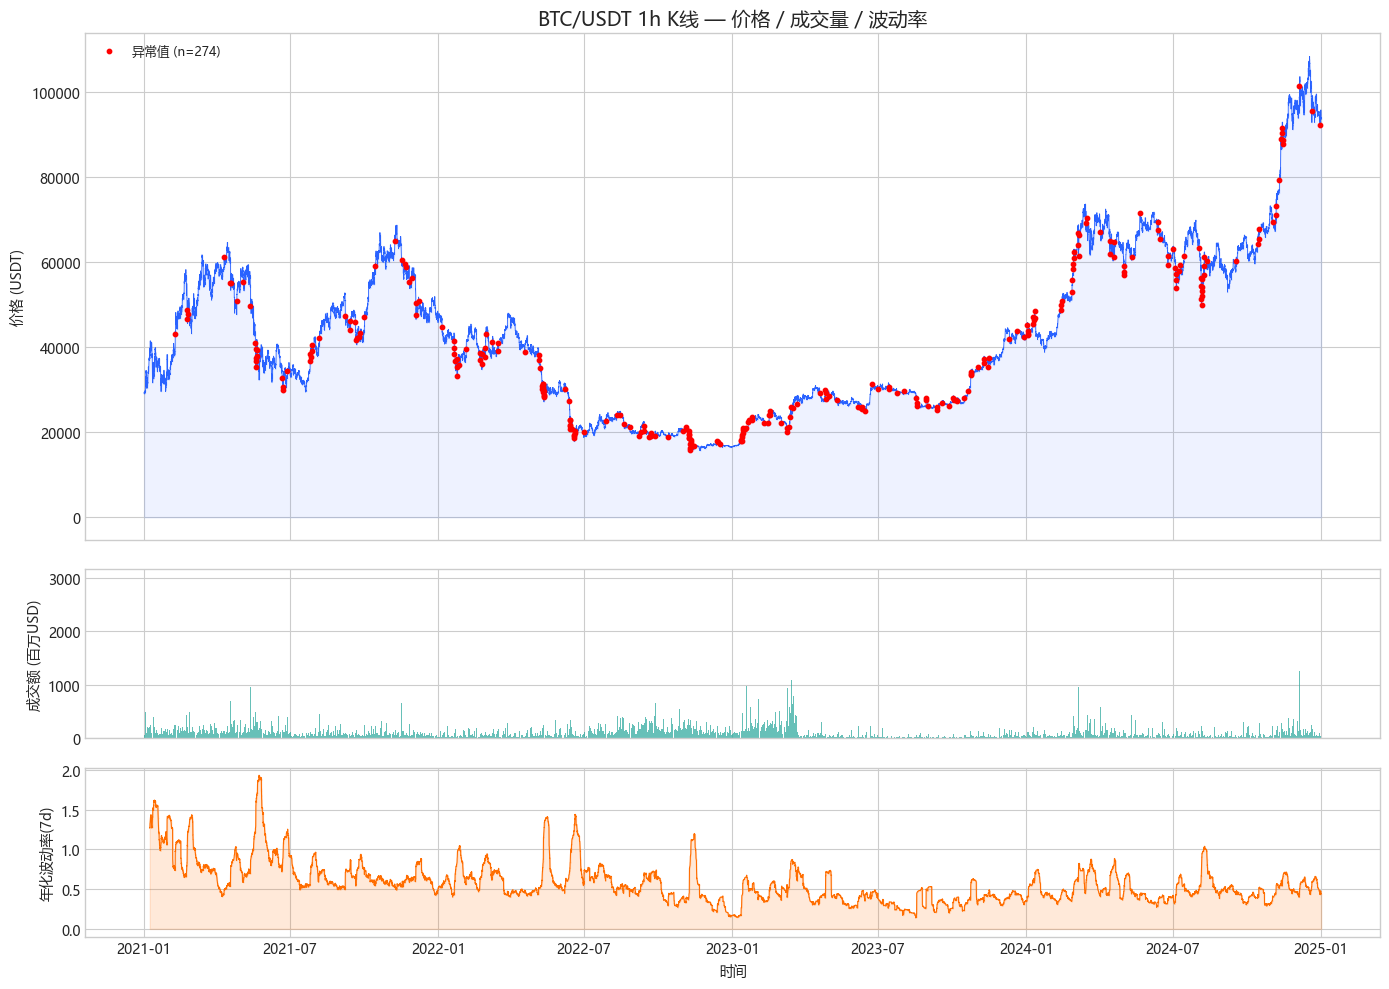

In [21]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})

# 价格
axes[0].plot(df_clean.index, df_clean['close'], linewidth=0.6, color='#2962FF')
axes[0].fill_between(df_clean.index, df_clean['close'], alpha=0.08, color='#2962FF')
axes[0].set_ylabel('价格 (USDT)')
axes[0].set_title(f"{CONFIG['symbol']} {CONFIG['timeframe']} K线 — 价格 / 成交量 / 波动率", fontsize=14)

# 标记异常值
anomaly_mask = df_clean['is_anomaly']
axes[0].scatter(df_clean.index[anomaly_mask], df_clean['close'][anomaly_mask],
                c='red', s=10, zorder=5, label=f'异常值 (n={anomaly_mask.sum()})')
axes[0].legend(fontsize=9)

# 成交量
axes[1].bar(df_clean.index, df_clean['volume_usd'] / 1e6, width=0.04,
            color='#26A69A', alpha=0.7)
axes[1].set_ylabel('成交额 (百万USD)')

# 滚动波动率
rolling_vol = df_clean['returns'].rolling(168).std() * np.sqrt(8760)
axes[2].plot(df_clean.index, rolling_vol, linewidth=0.8, color='#FF6D00')
axes[2].fill_between(df_clean.index, rolling_vol, alpha=0.15, color='#FF6D00')
axes[2].set_ylabel('年化波动率(7d)')
axes[2].set_xlabel('时间')

plt.tight_layout()
plt.show()

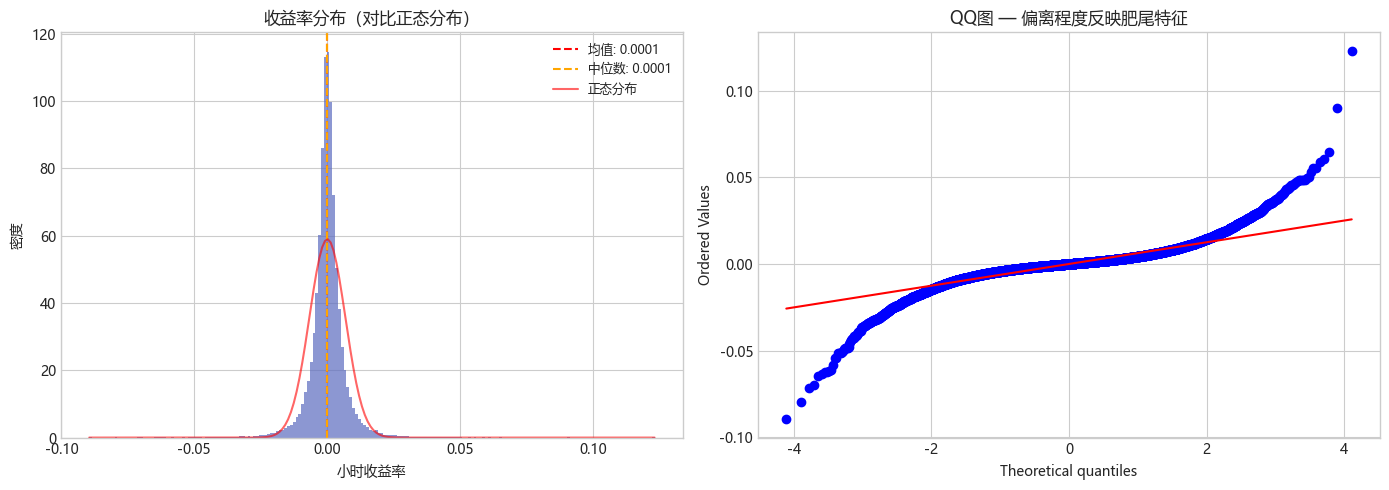


收益率统计:
  偏度(Skewness): -0.0207
  峰度(Kurtosis): 15.6525


In [22]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns = df_clean['returns'].dropna()

# 直方图
axes[0].hist(returns, bins=200, density=True, alpha=0.7, color='#5C6BC0', edgecolor='none')
axes[0].axvline(returns.mean(), color='red', linestyle='--', label=f'均值: {returns.mean():.4f}')
axes[0].axvline(returns.median(), color='orange', linestyle='--', label=f'中位数: {returns.median():.4f}')

# 叠加正态分布曲线
x = np.linspace(returns.min(), returns.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
             'r-', linewidth=1.5, alpha=0.6, label='正态分布')
axes[0].set_xlabel('小时收益率')
axes[0].set_ylabel('密度')
axes[0].set_title('收益率分布（对比正态分布）')
axes[0].legend(fontsize=9)

# QQ图
stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('QQ图 — 偏离程度反映肥尾特征')

plt.tight_layout()
plt.show()

print(f"\n收益率统计:")
print(f"  偏度(Skewness): {returns.skew():.4f}")
print(f"  峰度(Kurtosis): {returns.kurtosis():.4f}")

---
## 7. 数据持久化

保存为Parquet格式，后续Notebook直接读取，无需重新拉API。

In [23]:
import json

# 保存清洗后的数据
output_path = f"{CONFIG['data_dir']}/btc_usdt_1h_clean.parquet"
df_clean.to_parquet(output_path, engine='pyarrow')

# 保存配置信息
config_path = f"{CONFIG['data_dir']}/config.json"
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(CONFIG, f, ensure_ascii=False, indent=2)

# 验证
df_verify = pd.read_parquet(output_path)
file_size_mb = os.path.getsize(output_path) / (1024 * 1024)

print(f"数据已保存: {output_path}")
print(f"配置已保存: {config_path}")
print(f"文件大小: {file_size_mb:.1f} MB")
print(f"记录数: {len(df_verify):,}")
print(f"字段: {list(df_verify.columns)}")

数据已保存: ../data/btc_usdt_1h_clean.parquet
配置已保存: ../data/config.json
文件大小: 3.1 MB
记录数: 35,064
字段: ['open', 'high', 'low', 'close', 'volume', 'is_anomaly', 'returns', 'log_returns', 'typical_price', 'bar_range', 'volume_usd']


---
## 8. 数据接口

复制以下代码到后续Notebook开头，即可加载数据：

In [24]:
# ============================================
# 复制这段到其他Notebook开头即可加载数据
# ============================================
# import pandas as pd
# import json
#
# df = pd.read_parquet('../data/btc_usdt_1h_clean.parquet')
# with open('../data/config.json', 'r') as f:
#     CONFIG = json.load(f)
# print(f"已加载: {len(df):,} 条 {CONFIG['symbol']} {CONFIG['timeframe']} K线")

---
## 小结

**做了什么**
1. 通过ccxt从Binance拉取了2021-2024年BTC/USDT 1小时K线（35,064条）
2. 数据质量检查：完整度99.96%，无OHLC逻辑错误
3. 数据清洗：补全14条缺失K线，标记274个价格异常值，添加6个衍生字段
4. EDA：确认收益率呈肥尾分布（峰度15.65），极端行情频率远高于正态假设

**关键发现**
- 肥尾特征意味着策略设计必须重视尾部风险管理，不能仅依赖均值和标准差

**下一步**
- NB2: 经典技术指标策略 — 用均线交叉、RSI、布林带构建基线策略